In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.AAA.baryrat import aaa
from src.kernel_params.kernel_params import KernelParams
from src.kernel_matrix.kernel_matrix import KernelMatrix
from src.discr_error.discr_error import DiscrError
from src.spec_dens.spec_dens import spec_dens_gapless
from scipy import integrate
from src.utils.common_funcs import initialize_fine_grid

Project path successfully added.


In [66]:

#set up parameters for specified spectral densities 
#spec_dens = lambda omega:  np.sqrt(1 - omega**2) * 1/(1+ np.exp(10*(omega - 1))) * 1/(1+ np.exp(10*(omega + 1)))

def spec_dens(omega):
    omega = np.asarray(omega)  # Ensure omega is a NumPy array
    result = np.zeros_like(omega)  # Initialize result array with the same shape as omega
    
    mask = np.abs(omega) < 1  # Boolean mask for values where abs(omega) < 1
    result[mask] = np.sqrt(1 - omega[mask]**2)  # Apply the formula only where the condition is True
    
    return result

beta = 0
params = KernelParams(spec_dens = spec_dens, n = 300, m = 300, N_max = 20, h = 0.01, beta = beta, phi = 0)

#create KernelMatrix object with specified parameters which we will use as reference 
K = KernelMatrix(**params.params)
D = DiscrError(**params.params)


#explicitly get the fine frequency grid
fine_grid, _, Jacobian = initialize_fine_grid(params.get_param("m"), params.get_param("n"), params.get_param("h"), freq_parametrization= "simple_exp")

# frequency points in for negativ and positive part on real axis
Z = np.concatenate((-fine_grid[::-1], fine_grid)) 

# function values, determined by product of spectral density and Fermi Dirac distribution and Jacobian factor
F = spec_dens(Z) * 1/(1 + np.exp(- params.get_param("beta") * Z)) * params.get_param("h") * abs(Z)

print("parameters: ")
#h
print("h: ", params.get_param("h"))
#m
print("m: ", params.get_param("m"))
#n
print("n: ", params.get_param("n"))
#N_max
print("N_max: ", params.get_param("N_max"))
#delta_t
print("delta_t: ", params.get_param("delta_t"))
#beta
print("beta: ", params.get_param("beta"))



#perform AAA algorithm on spectral density multiplied with Fermi-Dirac distribution
r, errors = aaa(Z = Z, F = F, return_errors=True, mmax=(params.get_param("m") + params.get_param("n")))

#Frequency grids
print("Fine grid (for positive frequencies):\n", "first five: ", fine_grid[:5], "\n last five: ", fine_grid[-5:])
#print the first 5 nodes
print("Nodes: ", r.nodes[:5])
#print the first 5 poles
print("Poles: ", r.poles()[:5])

#compute the elements that appear in the denominator when computing the residues:
matrix = r.nodes[:,None]-r.poles()[None,:]


mask = abs(matrix) < 1e-10
print("The following elements are zero: \n", mask)

#poles, residues = r.polres()




parameters: 
h:  0.01
m:  300
n:  300
N_max:  20
delta_t:  0.1
beta:  0
Fine grid (for positive frequencies):
 first five:  [0.04978707 0.05028744 0.05079283 0.05130331 0.05181892] 
 last five:  [19.29797176 19.4919196  19.68781664 19.88568249 20.08553692]
Nodes:  [ -0.70468809 -18.91584631  -0.86935824   0.71892373   0.72614904]
Poles:  [ -0.70468809+0.j         -13.51417664+0.j
  -6.77648911+0.j           2.43895998+0.j
  -0.45614849+0.59946729j]
The following elements are zero: 
 [[ True False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [53]:
print(F.sum())
print(integrate.quad_vec(
    lambda x: spec_dens(x) * 1/(1 + np.exp(- params.get_param("beta") * x)),
    -11.0,
    11.0,
    epsabs=1.49e-6,
    epsrel=1.49e-6
) )



(0.3432701139314637+0.10544968647227249j)
(nan, nan)


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_27122/1664626024.py:2: RuntimeWarning: invalid value encountered in sqrt
  spec_dens = lambda omega:  np.sqrt(1 - (omega * 1/(1+ np.exp(10*(omega-0.95))))**2)


/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


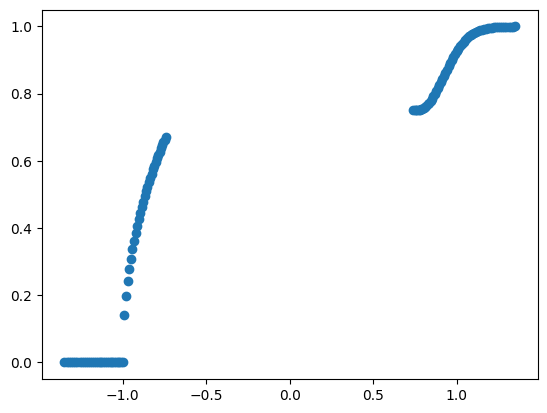

In [54]:
plt.figure()
plt.scatter(Z, spec_dens(Z))


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_27122/19286325.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axs[0].plot(poles.real, poles.imag, 'ro', label = 'Poles', color = 'blue')


Text(0, 0.5, 'Im')

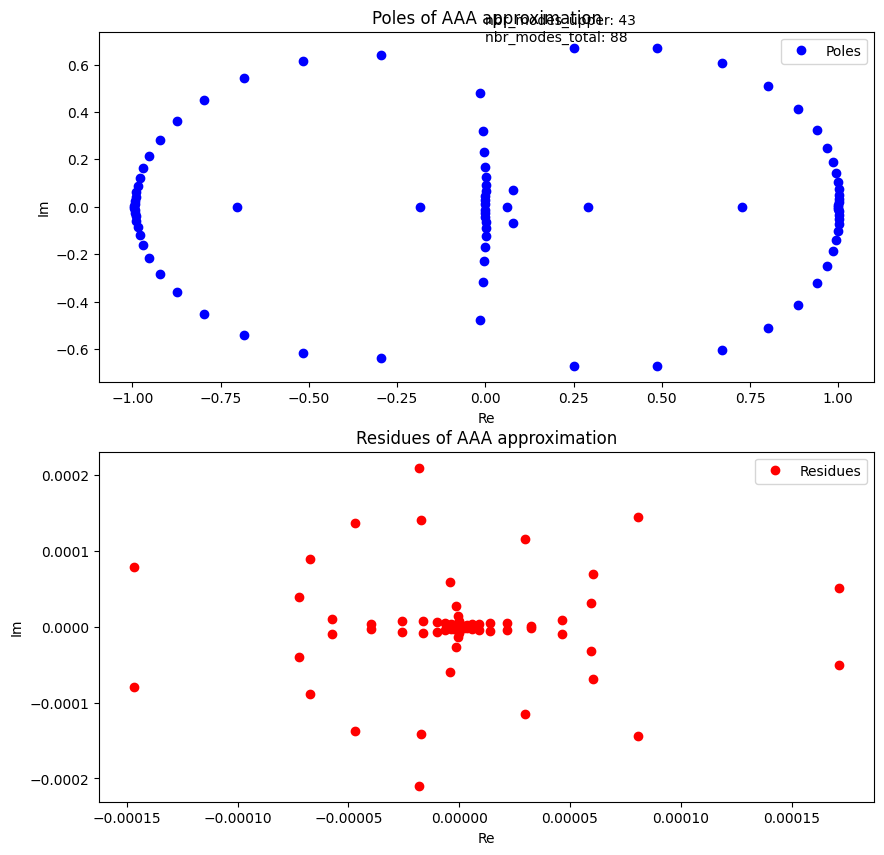

In [31]:
#plot the poles in the complex plane
#subplots in one figure
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
#plot the poles in the complex plane
axs[0].plot(poles.real, poles.imag, 'ro', label = 'Poles', color = 'blue')
axs[0].set_title('Poles of AAA approximation')
axs[0].legend()
axs[0].set_xlabel('Re')
axs[0].set_ylabel('Im')
axs[0].text(0,.7, 'nbr_modes_upper: ' + str(len(poles[poles.imag > 0])) + '\n' + 'nbr_modes_total: ' + str(len(poles)))

#plot the residues in the complex plane
axs[1].plot(residues.real, residues.imag, 'ro', label = 'Residues')
axs[1].set_title('Residues of AAA approximation')
axs[1].legend()
axs[1].set_xlabel('Re')
axs[1].set_ylabel('Im')





[            nan           +nanj -4.71266073e-05-1.37310099e-04j
  2.96777446e-05-1.15660958e-04j -1.46535289e-04-7.90759060e-05j
  6.03087563e-05-6.93104559e-05j -4.71266072e-05+1.37310098e-04j
  2.96777448e-05+1.15660958e-04j -1.46535288e-04+7.90759039e-05j
  6.03087564e-05+6.93104557e-05j  5.94166587e-05-3.13505542e-05j
  5.94166585e-05+3.13505541e-05j  4.65001327e-05-9.15483197e-06j
  4.65001328e-05+9.15483199e-06j  3.26010491e-05+1.09516500e-06j
  3.26010491e-05-1.09516501e-06j  2.15911812e-05-4.60664706e-06j
  2.15911812e-05+4.60664709e-06j  1.38994205e-05-4.98300538e-06j
  1.38994205e-05+4.98300539e-06j  8.83775787e-06-4.17774415e-06j
  8.83775787e-06+4.17774415e-06j  5.59172696e-06-3.09196567e-06j
  5.59172696e-06+3.09196567e-06j  3.52053464e-06-2.07780257e-06j
  3.52053464e-06+2.07780257e-06j  2.18570181e-06-1.24004184e-06j
  2.18570181e-06+1.24004184e-06j  1.30001070e-06-5.84320850e-07j
  6.75604422e-07-1.10836234e-07j  6.75604422e-07+1.10836234e-07j
  1.30001070e-06+5.843208

Text(0.5, 0, 'Frequency $\\omega$')

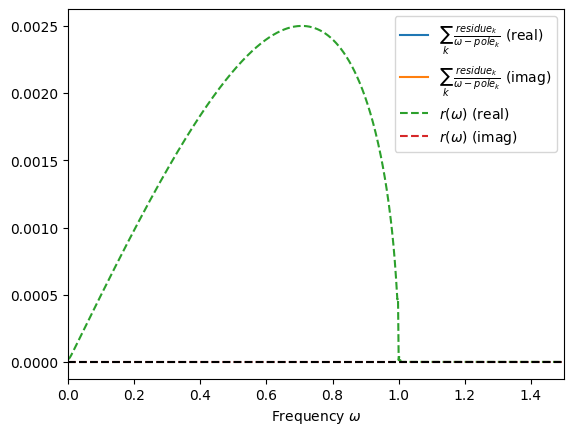

In [33]:
#check that sum over residues divided by poles gives r(z)

#define function as r_check(x) = sum_k residue_k / (x - pole_k)
r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues, poles)])

print(residues)
#range in which we want to plot the function
x_range = np.linspace(0,20,10000)

#evaluate r_check(x) for each x in x_range
vals = np.array([r_check(x) for x in x_range])

print(np.allclose(vals, r(x_range)))
print(vals[:10], r(x_range)[:10])

#plot the real and imaginary part of r(x) and the real and imaginary part of r_check(x)
plt.figure()
plt.plot(x_range, vals.real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' )
plt.plot(x_range, vals.imag, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (imag)' )
plt.plot(x_range, np.real(r(x_range)), label = r'$r(\omega)$' + ' (real)' , linestyle = '--')
plt.plot(x_range, np.imag(r(x_range)), label = r'$r(\omega)$' + ' (imag)' , linestyle = '--')
#for i in range(len(poles)):
#    plt.plot(x_range, residues[i] / (x_range - poles[i]), label = 'residue ' + str(i))
plt.hlines(0, 0, 10, color = 'k', linestyle = '--')
plt.legend()
plt.xlim(0, 1.5)
plt.xlabel('Frequency ' + r'$\omega$')

Text(0, 0.5, 'Error')

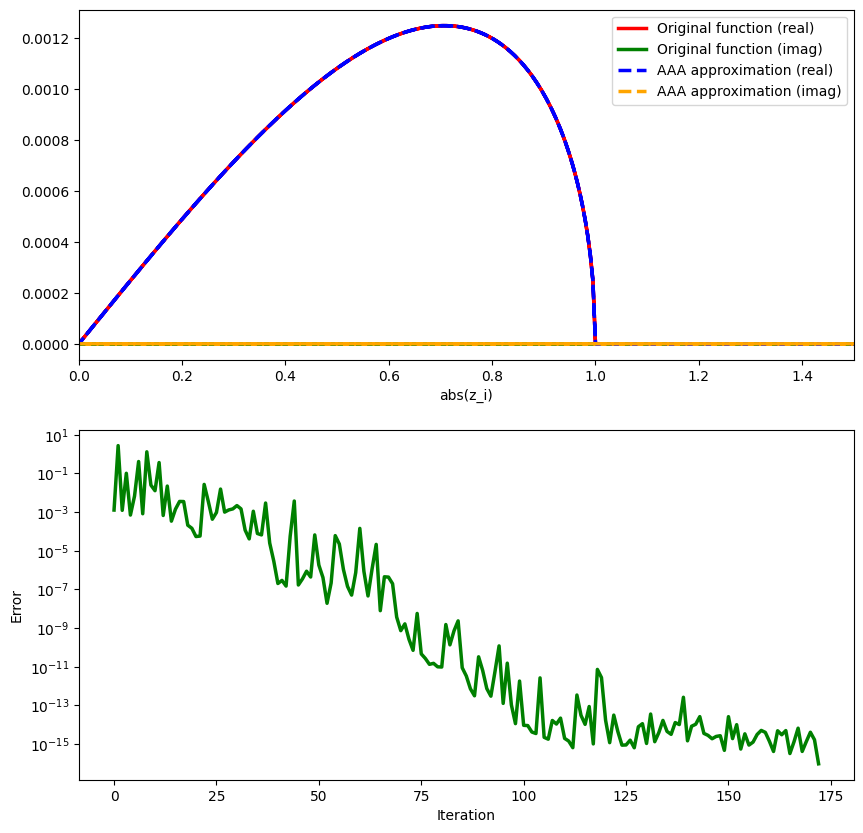

In [7]:

#check that the function is correctly approximated

F_AAA = r(Z) #values computed based on the AAA approximation

#figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
#first plot original and reconstructed function
axs[0].plot(abs(Z), F.real, label = 'Original function (real)', linewidth = 2.5, color = 'red')
axs[0].plot(abs(Z), F.imag, label = 'Original function (imag)', linewidth = 2.5, color = 'green')
axs[0].plot(abs(Z), F_AAA.real, label = 'AAA approximation (real)', linestyle = '--', linewidth = 2.5, color = 'blue')
axs[0].plot(abs(Z), F_AAA.imag, label = 'AAA approximation (imag)', linestyle = '--', linewidth = 2.5, color = 'orange')
#f_analyt = 1/(1+np.exp(-beta* Z))  * spec_dens(Z) * Jacobian * np.exp(1.j * np.pi/4)
#axs[0].plot(abs(Z), np.real(f_analyt), label = 'Explicit formula', linestyle = 'dotted', linewidth = 2.5, color = 'black')
axs[0].legend()
axs[0].set_xlabel('abs(z_i)')
axs[0].set_xlim(0, 1.5)
#axs[0].text(0, 1.5, 'f(x) = n(x) * Gamma(x) * Jac(x)\n' +"with " + 'Gamma(x) = sqrt(100 - omega**2)', fontsize = 12)
#plot the error as function of iteration
axs[1].plot(errors, label = 'Error', linewidth = 2.5, color = 'green')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Error')



/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


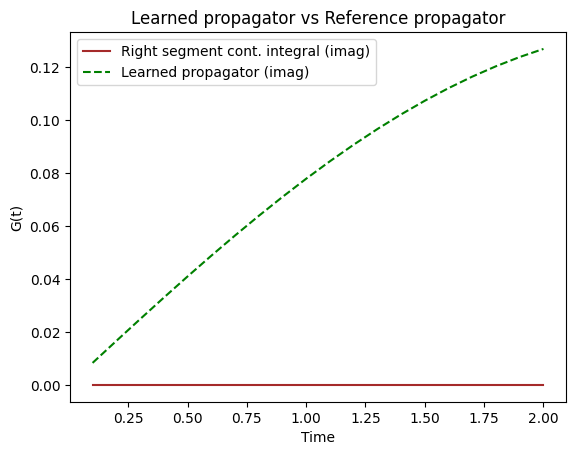

In [8]:
# Vectorized integration for real and imaginary parts
right_segment_cont = np.array([integrate.quad_vec(
    lambda x: 0.5 * r(x) /(x * 0.01) * np.exp(1.j * x * t),
    -np.inf,
    np.inf,
    epsabs=1.49e-6,
    epsrel=1.49e-6
) for t in K.times])

exact_integral  = np.array([integrate.quad_vec(
    lambda x: spec_dens(x) * 1/(1 + np.exp(- params.get_param("beta") * x)) 
 * np.exp(1.j * x * t),
    -np.inf,
    np.inf,
    epsabs=1.49e-6,
    epsrel=1.49e-6
) for t in K.times])



#check that "learned propagator is close to the reference propagator"
residues_upper = residues[poles.imag > 0]
poles_upper = poles[poles.imag > 0]


#sum over all modes
G_learned = 1.j * np.pi * np.sum(residues_upper / (poles_upper * 0.01) * np.exp(1.j * poles_upper * K.times[:,np.newaxis]), axis=1)

#G_ref = K.discrete_integral()

#continuous_integral = D.cont_integral()

#plot the learned propagator and the reference propagator
#plt.plot(K.times, continuous_integral.real, label='Cont. integral (real)', color = 'black', linestyle = 'dotted')
#plt.plot(K.times, continuous_integral.imag, label='Cont. integral (imag)', color = 'black', linestyle = 'dotted')
#plt.plot(K.times, right_segment_cont[:,0], label='Right segment cont. integral (real)', color = 'purple', linestyle = '-')
plt.plot(K.times, right_segment_cont[:,1], label='Right segment cont. integral (imag)', color = 'brown', linestyle = '-')
#plt.plot(K.times, G_learned.real, label='Learned propagator (real)', color = 'red', linestyle = '--')
plt.plot(K.times, G_learned.imag, label='Learned propagator (imag)', color = 'green', linestyle = '--')
#plt.plot(K.times, exact_integral[:,0], label='Exact propagator (real)', color = 'blue', linestyle = '-')
#plt.plot(K.times, exact_integral[:,1], label='Exact propagator (imag)', color = 'orange', linestyle = '-')
        
#plt.plot(K.times, G_ref.real, label='Reference propagator (real)', color = 'blue', linestyle = '--')
#plt.plot(K.times, G_ref.imag, label='Reference propagator (imag)', color = 'orange', linestyle = '--')
plt.legend()
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Learned propagator vs Reference propagator')
plt.show()
